In [1]:
!pip install tensorflow==2.15.0
!pip install librosa
!pip install soundfile
!pip install matplotlib
!pip install scipy
!pip install tqdm
!pip install gitpython

In [2]:
!git clone https://github.com/breizhn/DTLN.git

fatal: destination path 'DTLN' already exists and is not an empty directory.


In [3]:
import os
import librosa
import librosa.display
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio

In [4]:
audio_path = "noisy_speech.wav"
y, sr = librosa.load(audio_path, sr=16000, mono=True)
print("Sample Rate:", sr)
print("Duration:", len(y)/sr, "seconds")
Audio(y, rate=sr)

/opt/anaconda3/envs/quantization/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample Rate: 16000
Duration: 15.1253125 seconds


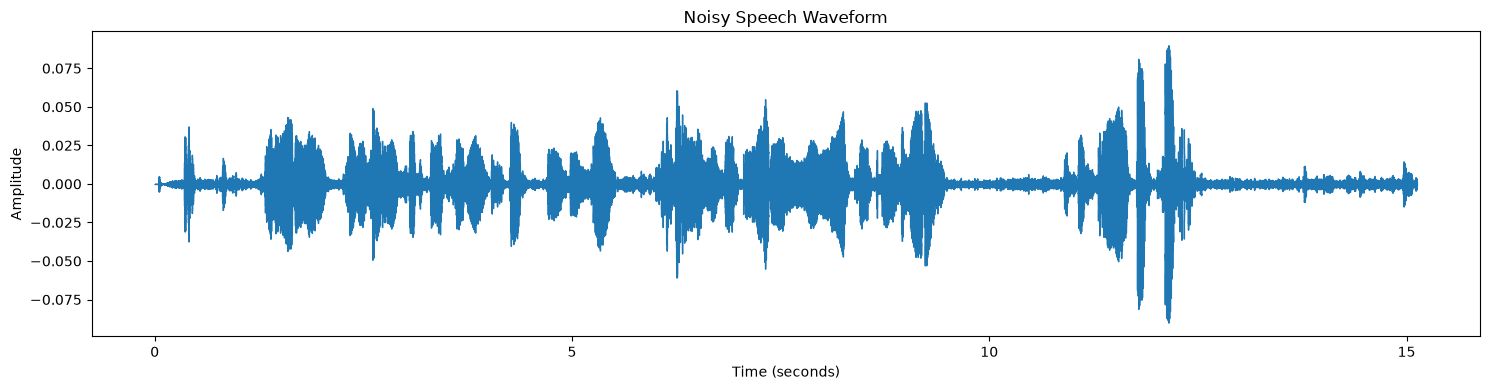

In [5]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(15,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Noisy Speech Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

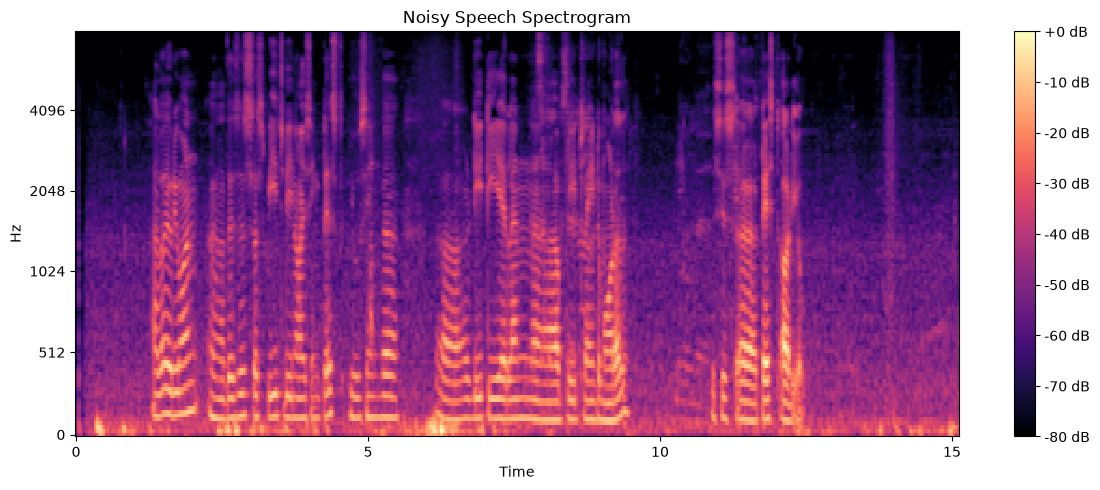

In [6]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format="%+2.0f dB")
plt.title("Noisy Speech Spectrogram")

plt.tight_layout()
plt.show()

In [7]:
import os

print(os.listdir("DTLN"))


['convert_weights_to_onnx.py', 'input_audio', 'run_evaluation.py', 'pretrained_model', 'real_time_processing.py', 'LICENSE', 'real_time_dtln_audio.py', 'real_time_processing_onnx.py', 'eval_env.yml', '__pycache__', 'README.md', 'DTLN_model.py', 'convert_weights_to_saved_model.py', 'train_env.yml', 'tflite_env.yml', 'convert_weights_to_tf_lite.py', '.ipynb_checkpoints', 'output_audio', 'noisy_speech.wav', 'real_time_processing_tf_lite.py', 'measure_execution_time.py', '.git', 'run_training.py']


In [8]:
import shutil

shutil.copy("noisy_speech.wav", "DTLN/noisy_speech.wav")

'DTLN/noisy_speech.wav'

In [12]:
!ls input_audio

noisy_speech.wav


In [15]:
!python run_evaluation.py \
    --model pretrained_model/model.h5 \
    --in_folder input_audio \
    --out_folder output_audio

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None)]               0         []                            
                                                                                                  
 lambda (Lambda)             [(None, None, 257),          0         ['input_1[0][0]']             
                              (None, None, 257)]                                                  
                                                                                                  
 lstm (LSTM)                 (None, None, 128)            197632    ['lambda[0][0]']              
                                                                                                  
 dropout (Dropout)           (None, None, 128)            0         ['lstm[0][0]']            

In [17]:
import os

input_size = os.path.getsize("input_audio/noisy_speech.wav")
output_size = os.path.getsize("output_audio/noisy_speech.wav")

print("Input size :", input_size)
print("Output size:", output_size)

Input size : 484088
Output size: 484054


In [18]:
from IPython.display import Audio

Audio("output_audio/noisy_speech.wav")

In [20]:
from IPython.display import Audio

print("Original")
display(Audio("input_audio/noisy_speech.wav"))

print("Denoised")
display(Audio("output_audio/noisy_speech.wav"))

Original


Denoised


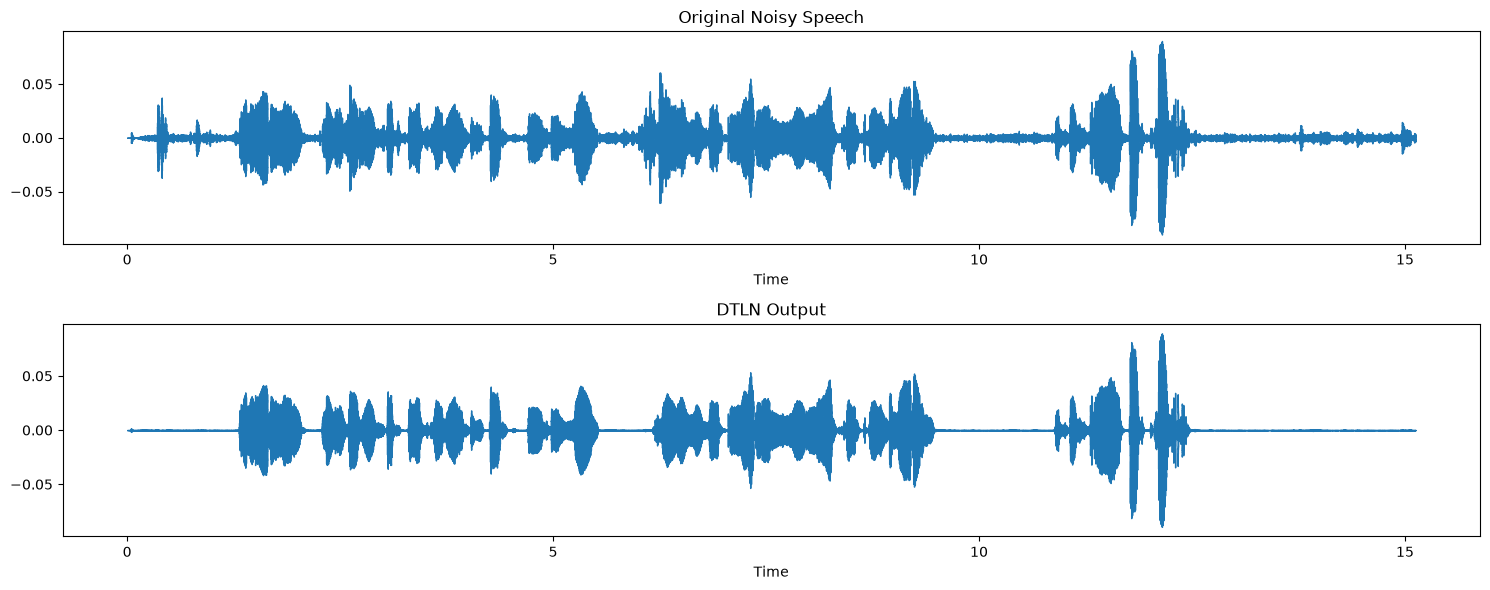

In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

y_in, sr = librosa.load("input_audio/noisy_speech.wav", sr=None)
y_out, _ = librosa.load("output_audio/noisy_speech.wav", sr=None)

plt.figure(figsize=(15,6))

plt.subplot(2,1,1)
librosa.display.waveshow(y_in, sr=sr)
plt.title("Original Noisy Speech")

plt.subplot(2,1,2)
librosa.display.waveshow(y_out, sr=sr)
plt.title("DTLN Output")

plt.tight_layout()
plt.show()

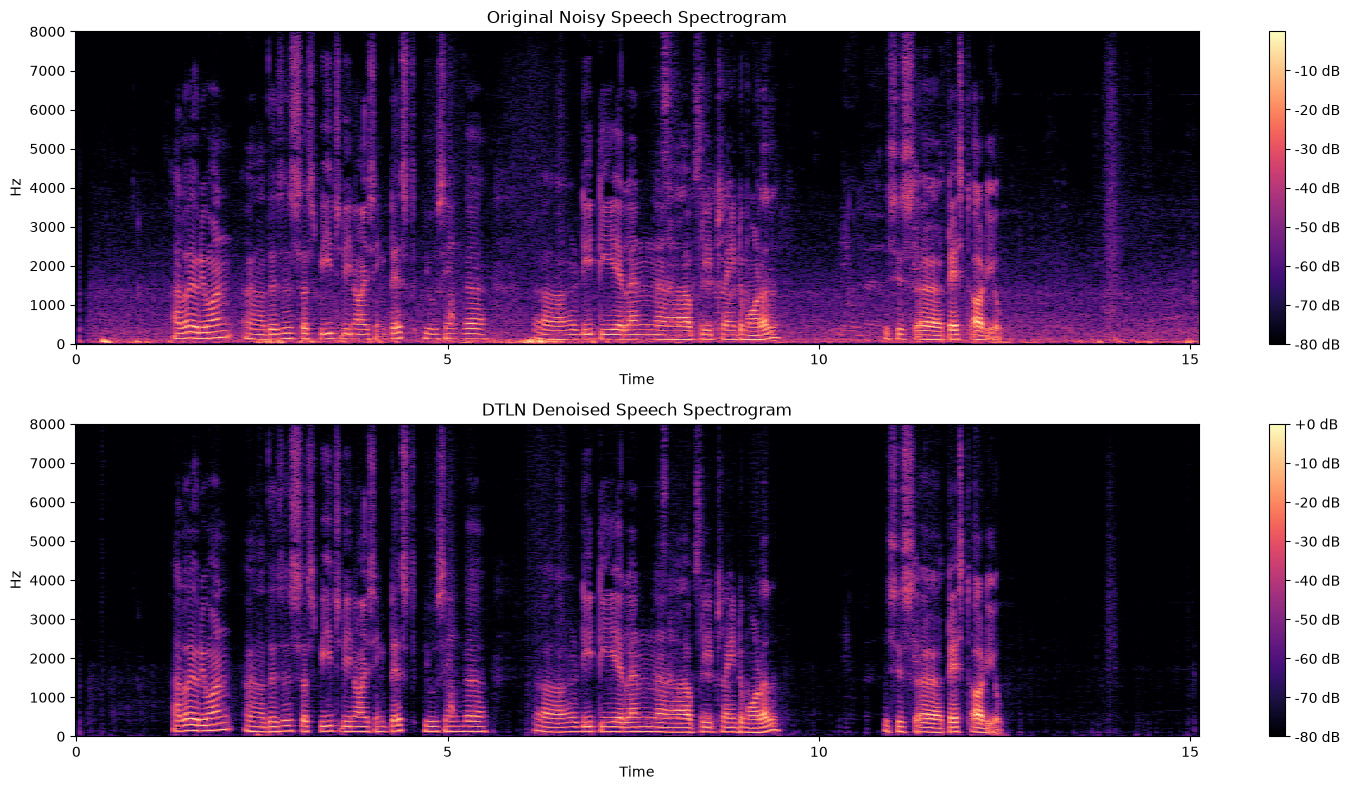

In [22]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

y_in, sr = librosa.load("input_audio/noisy_speech.wav", sr=None)
y_out, _ = librosa.load("output_audio/noisy_speech.wav", sr=None)

plt.figure(figsize=(15,8))

# Original
plt.subplot(2,1,1)
S1 = librosa.amplitude_to_db(np.abs(librosa.stft(y_in)), ref=np.max)
librosa.display.specshow(S1, sr=sr, x_axis="time", y_axis="hz")
plt.title("Original Noisy Speech Spectrogram")
plt.colorbar(format="%+2.0f dB")

# Denoised
plt.subplot(2,1,2)
S2 = librosa.amplitude_to_db(np.abs(librosa.stft(y_out)), ref=np.max)
librosa.display.specshow(S2, sr=sr, x_axis="time", y_axis="hz")
plt.title("DTLN Denoised Speech Spectrogram")
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

- The pretrained DTLN model successfully processed the noisy speech recording.
- Background noise in silent regions was significantly reduced.
- The waveform of the denoised signal shows cleaner silence and more distinct speech segments.
- The spectrogram shows reduced low-energy noise while preserving the main speech frequencies.
- Listening to the output confirms that speech intelligibility is improved with less background noise.